In [3]:
import numpy as np
# sheep_path = [[] for _ in range(1)]
sheep_path = [[(0,0),(1,1),(2,2)],[(0,0),(1,1),(2,2)]]
path = np.zeros_like(sheep_path)
path

array([[[0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0]]])

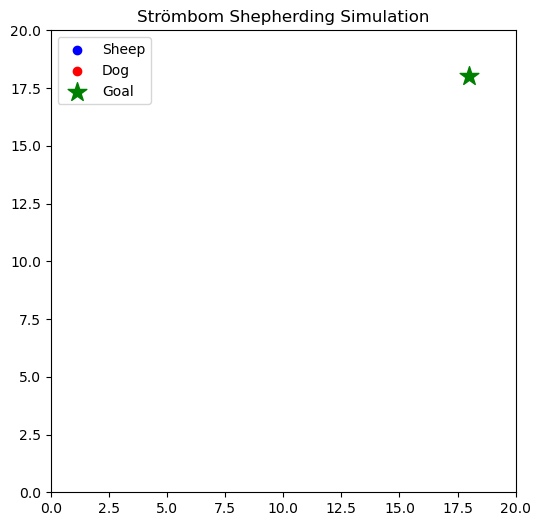

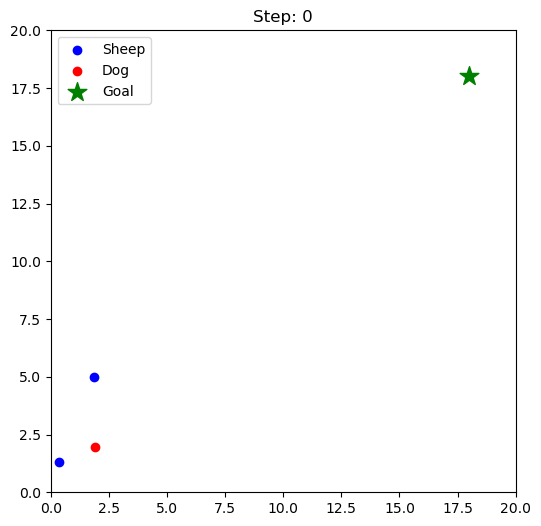

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Parameters ----------
num_sheep = 2
num_dogs = 1
grid_size = 20.0

dt = 0.1  # timestep

# Sheep parameters
sheep_max_speed = 0.5
sheep_noise = 0.05
K_dog = 2.0   # repulsion strength from dog
dog_influence_radius = 2.0

# Dog parameters
dog_speed = 1.0
herd_radius = 3.0  # radius to define herd center

# Goal
goal = np.array([18.0, 18.0])

# ---------- Initialize positions ----------
sheep_pos = np.random.rand(num_sheep, 2) * grid_size
dog_pos = np.array([[2.0, 2.0]])

# ---------- Helper functions ----------
def herd_center(sheep):
    return np.mean(sheep, axis=0)

def move_sheep(sheep, dog):
    new_sheep = np.copy(sheep)
    for i, s in enumerate(sheep):
        # Random movement
        vel = (np.random.rand(2) - 0.5) * sheep_noise

        # Repulsion from dog
        for d in dog:
            r = s - d
            dist = np.linalg.norm(r)
            if dist < dog_influence_radius:
                vel += K_dog * r / (dist + 1e-5)

        # Limit speed
        speed = np.linalg.norm(vel)
        if speed > sheep_max_speed:
            vel = vel / speed * sheep_max_speed

        new_sheep[i] += vel * dt
        # Keep inside grid
        new_sheep[i] = np.clip(new_sheep[i], 0, grid_size)
    return new_sheep

def move_dog(dog, sheep):
    center = herd_center(sheep)
    # Position dog behind herd relative to goal
    direction = center - goal
    direction = direction / (np.linalg.norm(direction) + 1e-5)
    target = center + direction * herd_radius

    # Move dog towards target
    vel = target - dog[0]
    speed = np.linalg.norm(vel)
    if speed > dog_speed:
        vel = vel / speed * dog_speed

    dog[0] += vel * dt
    dog[0] = np.clip(dog[0], 0, grid_size)
    return dog

# ---------- Simulation ----------
steps = 200

plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

for t in range(steps):
    sheep_pos = move_sheep(sheep_pos, dog_pos)
    dog_pos = move_dog(dog_pos, sheep_pos)

    ax.clear()
    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_title(f"Step: {t}")
    ax.scatter(sheep_pos[:,0], sheep_pos[:,1], c='blue', label='Sheep')
    ax.scatter(dog_pos[:,0], dog_pos[:,1], c='red', label='Dog')
    ax.scatter(goal[0], goal[1], c='green', marker='*', s=200, label='Goal')
    ax.legend()
    plt.pause(0.05)

plt.ioff()
plt.show()
